# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [14]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [16]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 1            # Thickness of each vertical bar
angles = np.arange(0, 190, 10)

# Query the surveys

In [17]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [18]:
# Compute the union of the survey geometries and simplify the result
survey_union = survey_gdf.unary_union.simplify(2)  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [19]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (345910.28845 5793289.221935)


In [20]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
# Generate 

<Axes: >

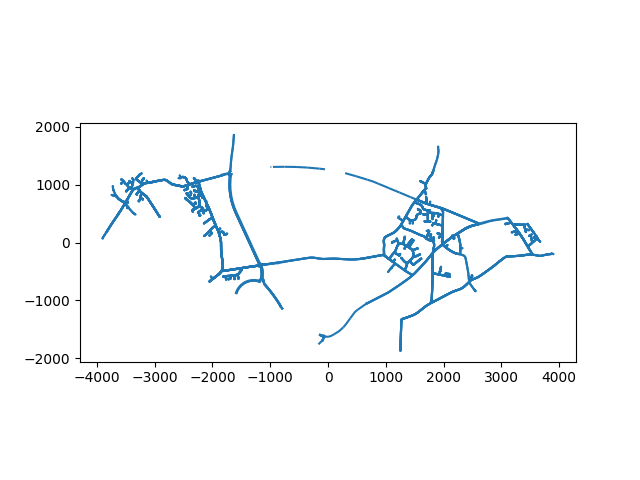

In [21]:
survey_gdf.set_geometry('geometry', inplace=True)
survey_gdf.plot()

# Generate the grid

In [22]:
output_gdf = gpd.GeoDataFrame()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for angle in angles:
            #print(f'Processing angle: {angle}')
            # Parameters for evenly spaced thin vertical rectangles (grid "bars")
            bounds = survey_union_offset_gdf.total_bounds
            min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
            r_x = np.sqrt(max_x**2 + max_y**2)
            r_y = np.sqrt(min_x**2 + min_y**2)

            # Compute number of columns safely and cast to int
            num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

            # Compute bar center x-positions
            x_centers = np.linspace(-r_x, r_x, num=num_cols)

            # For each center, form a thin rectangle
            vertical_bars = [
                Polygon([
                    (x - dx/2, min_y),
                    (x + dx/2, min_y),
                    (x + dx/2, max_y),
                    (x - dx/2, max_y)
                ])
                for x in x_centers
            ]

            #-- Grid aligned with the base vectors [1.0], 
            grid_lines_gdf = gpd.GeoDataFrame({'geometry': vertical_bars}, crs='EPSG:3857', geometry='geometry')
            grid_lines_gdf['grid_idx'] = grid_lines_gdf.index

            # Define the vector
            vec = np.array([1,0])
            ortho_vec = np.array([0,1])
            # Define a rotation angle in radians (example: 45 degrees)
            theta = np.deg2rad(angle)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta), np.cos(theta)]
            ])

            # Rotate the vector by the rotation matrix
            rotated_vec = rotation_matrix @ vec
            ortho_vec = rotation_matrix @ ortho_vec

            # Rotate the grid lines accordingly
            vertical_bars_r = [rotate(bar, angle=angle, origin=(0,0)) for bar in vertical_bars]
            grid_lines_gdf_r = gpd.GeoDataFrame({'geometry': vertical_bars_r}, crs='EPSG:3857', geometry='geometry')
            grid_lines_gdf_r['grid_idx'] = grid_lines_gdf_r.index

            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf_r, 
                survey_union_offset_gdf, 
                how='intersection', 
                keep_geom_type=False
            )
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.set_crs('EPSG:3857', inplace=True)

            try:
                #Get the bottom points of the intersected rectamgles
                intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(get_bottom_points)
            except Exception as e:
                print(f'No bottom points for angle {angle}')
                print(intersection_gdf['geometry'])
                print(e)

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))

            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle'], 0, atol=tol_deg)]
            if len(right_angles) > 0:
                #print('There is a right angle')
                #Get the cell boundaries
                right_angles['cell_boundary'] = right_angles.apply(lambda row: get_line_from_angle(row, ortho_vec), axis=1)

                #Rename the grid_idx to include the angle
                right_angles['grid_idx'] = right_angles.apply(lambda row: f"{row['grid_idx']}_{angle}", axis=1)
                right_angles.reset_index(drop=True)
                output_gdf = pd.concat([output_gdf, right_angles])

# Remove entries whose cell_boundary length > 1 std above the mean
lengths = output_gdf.cell_boundary.length
mean_length = lengths.mean()
std_length = lengths.std()
filtered_output_gdf = output_gdf[lengths <= (mean_length + std_length/2)]


#Remove all the intersecting 
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in filtered_output_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})


3928 splitters -> 4434 cells


## Count the intersections by cell

In [23]:
# Ensure the cell_offset_gdf is a GeoDataFrame, not a GeoSeries
cell_offset_gdf = gpd.GeoDataFrame(geometry=cell_gdf.buffer(-0.05), crs=cell_gdf.crs)

In [24]:
# Instead of using overlay (which only works for GeoDataFrames), do direct intersection between survey_gdf and cell_offset_gdf boundaries

# Get the boundaries as a GeoDataFrame
cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary, crs=cell_offset_gdf.crs)

points = gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode()
# Segment the survey_gdf into its individual line segments

/tmp/ipykernel_43004/986452470.py:6: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  points = gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode()


<Axes: >

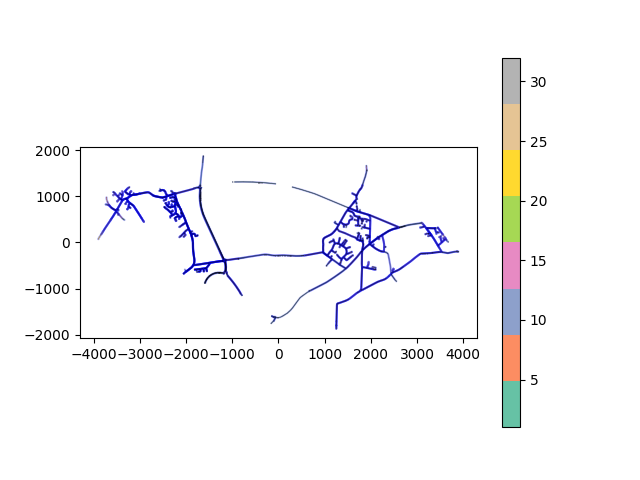

In [ ]:
fig,axr = plt.subplots()
# Merge cell_gdf with the grouped join result on cell_idx and index_right
joined_gdf = gpd.sjoin(points, cell_gdf, how='left', predicate='intersects')
# Get intersection counts by cell
cell_counts = joined_gdf.groupby('index_right').size().reset_index(name='count')

# Merge with cell_gdf to add count to each cell using left join
cell_gdf_with_count = cell_gdf.merge(cell_counts, left_on='cell_idx', right_on='index_right', how='left')
cell_gdf_with_count['passes'] = cell_gdf_with_count['count'] /2
# Plot the grids and survey_gdf on the same axes so both show up
cell_gdf_with_count.plot(ax=axr,column='passes', cmap='Set2', legend=True)
survey_gdf.plot(ax=axr, color='blue', alpha=0.2)